In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

In [3]:
with rasterio.open('../../dropbox/get_wp_global/output/abw_m_10_2020_CN_1km_R2025A_UA_v1.tif') as s:
    trf = s.transform
    prf = s.profile
    arr = s.read(1)

In [13]:
r,c = np.where(arr>0)

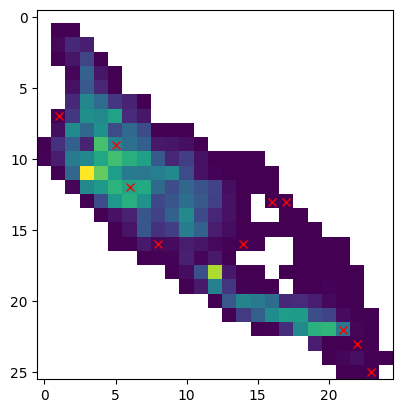

In [18]:
a = np.random.choice(range(len(c)), size=10, replace=False)
fig,ax = plt.subplots()
ax.imshow(arr)
ax.plot(c[a], r[a], 'xr')
plt.show()

In [19]:
x,y = rasterio.transform.xy(trf, r[a], c[a])

In [20]:
trf

Affine(0.0083333333, 0.0, -70.06666710639998,
       0.0, -0.0083333333, 12.6250002855)

In [31]:
geom = gpd.points_from_xy(x, y, crs=4326)
gdf = gpd.GeoDataFrame({'id':np.arange(len(x)), 'geometry':geom})
gdf.to_file('../data/abw_test_point.gpkg', index=False)

<Axes: >

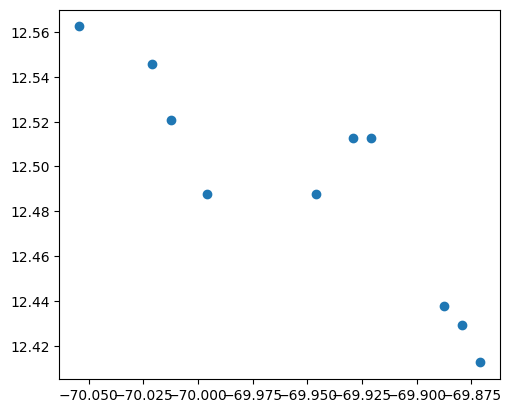

In [30]:
gdf.plot()